In [8]:
pip install opencv-contrib-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


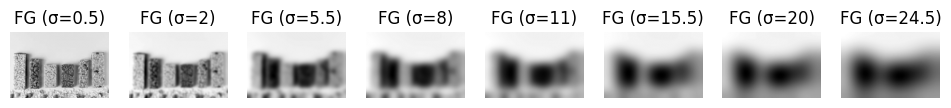

Las imágenes filtradas se han guardado correctamente.


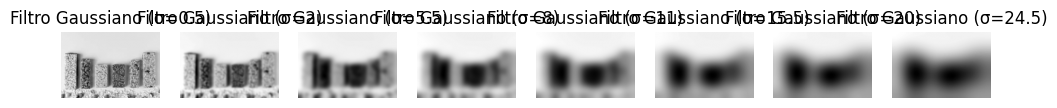

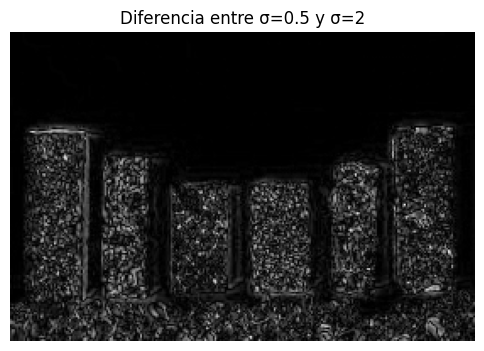

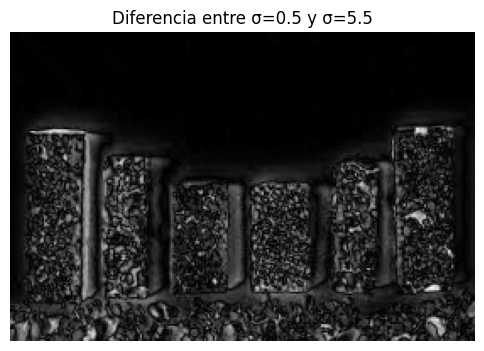

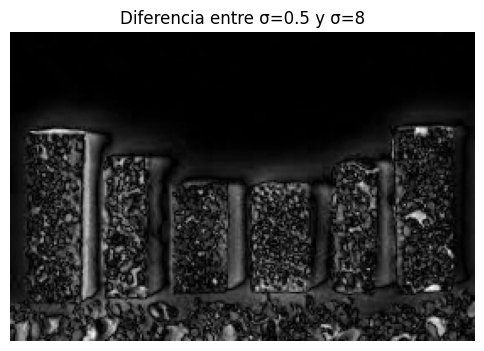

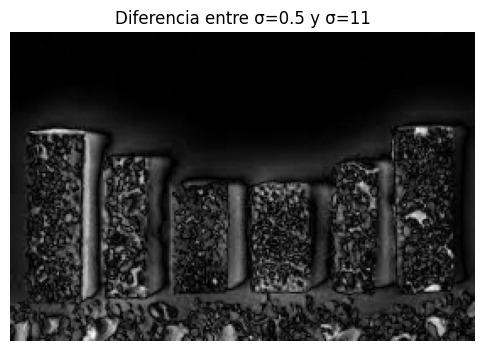

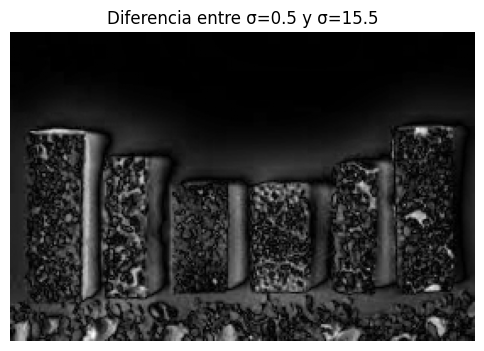

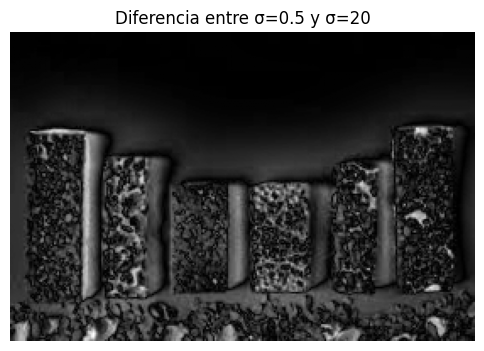

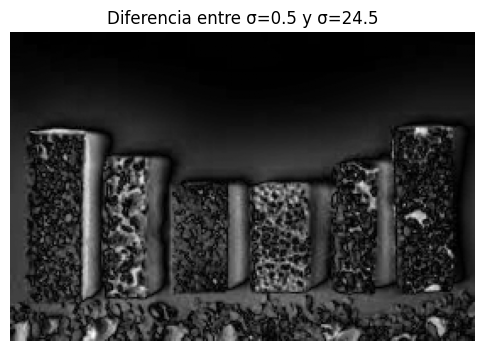

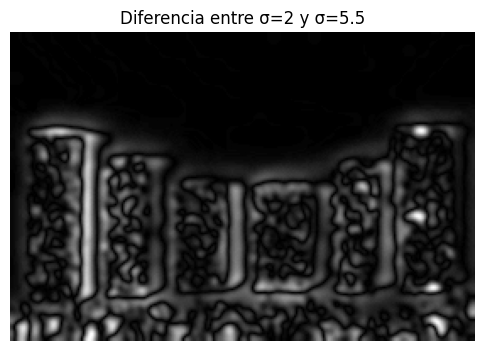

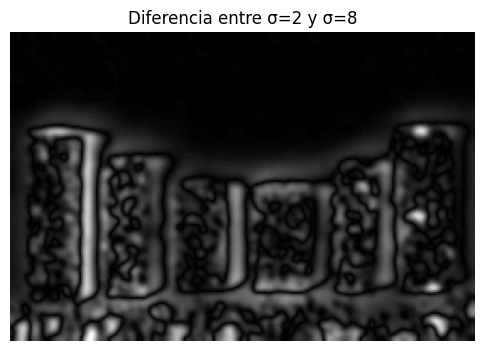

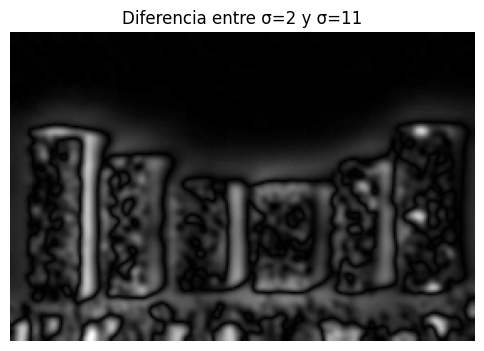

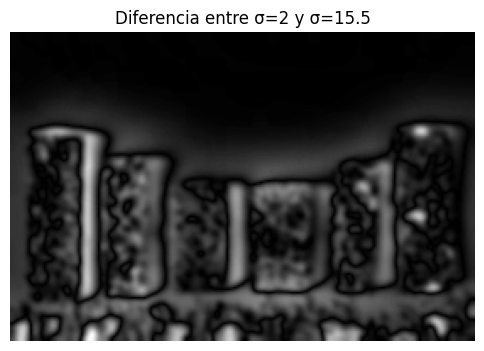

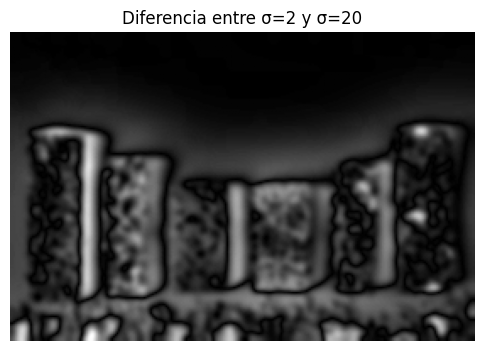

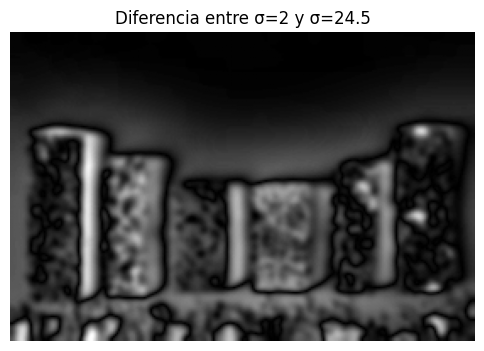

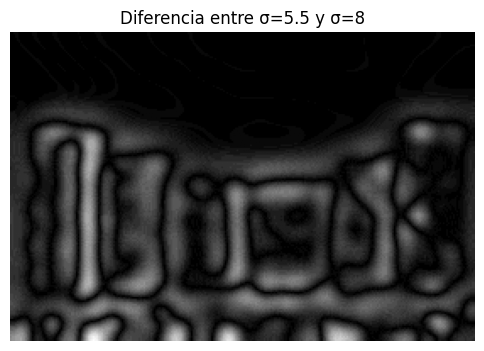

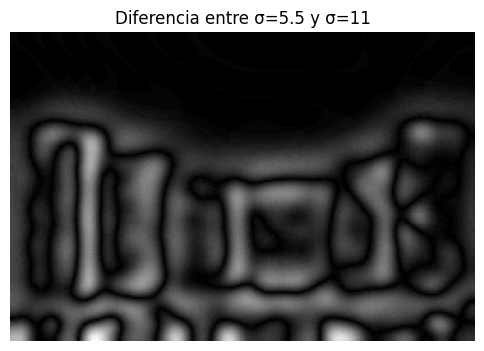

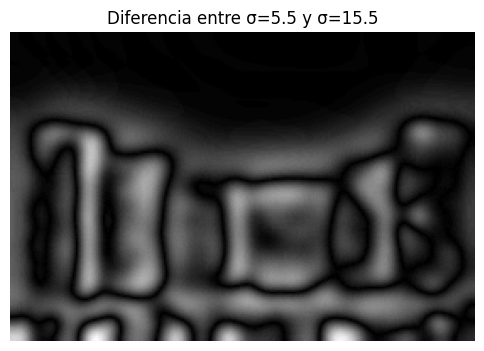

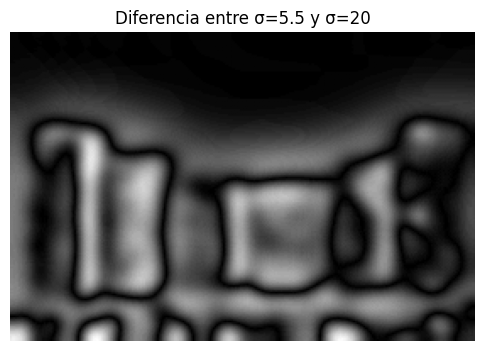

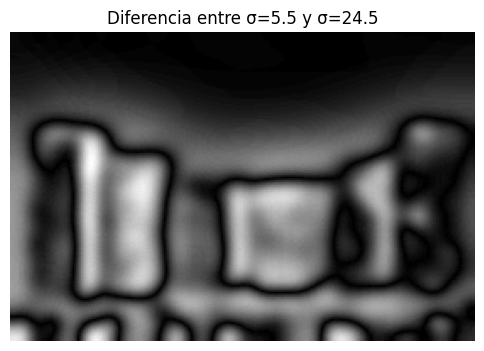

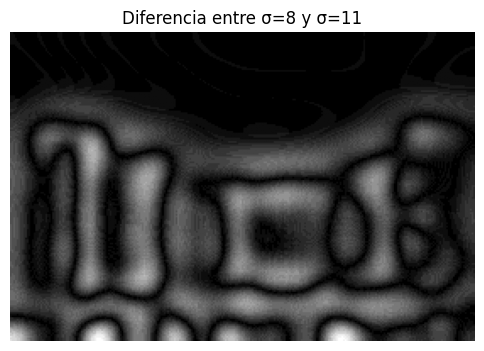

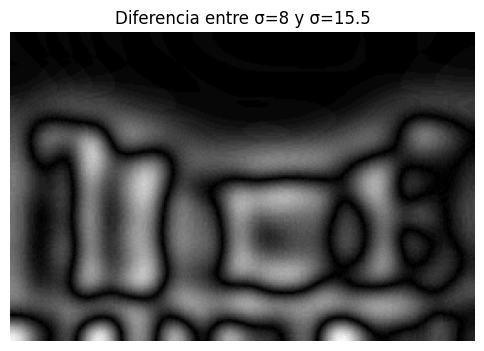

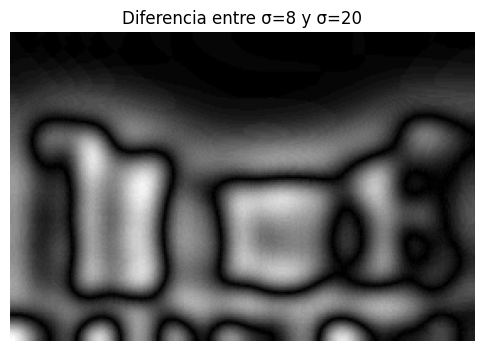

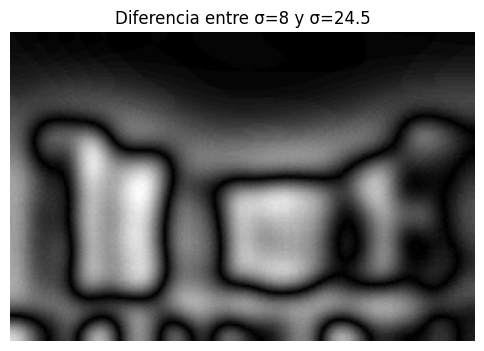

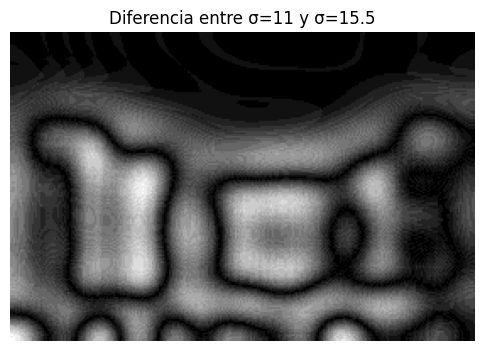

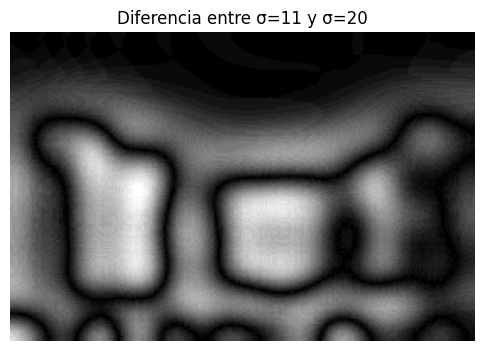

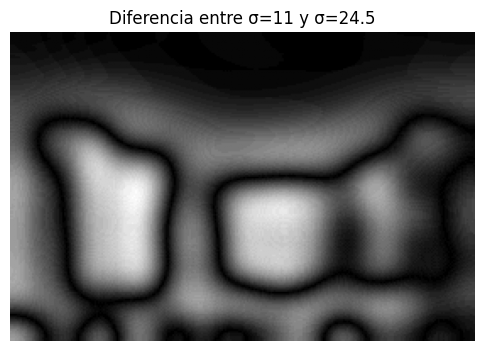

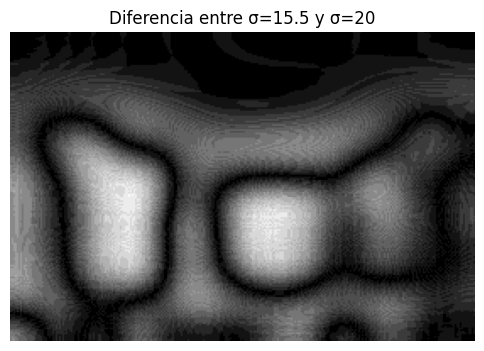

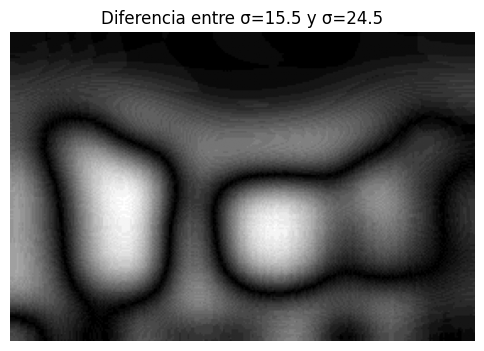

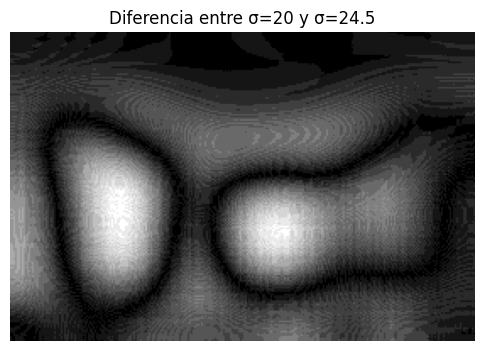

Las diferencias entre las imágenes han sido calculadas y guardadas correctamente.


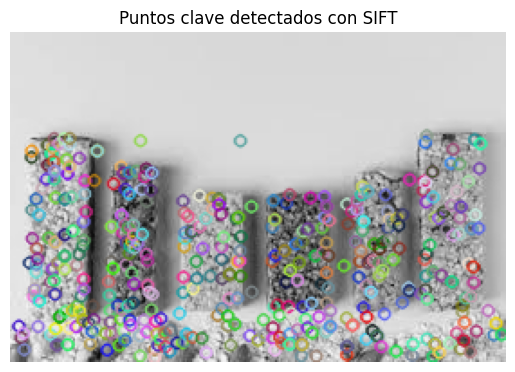

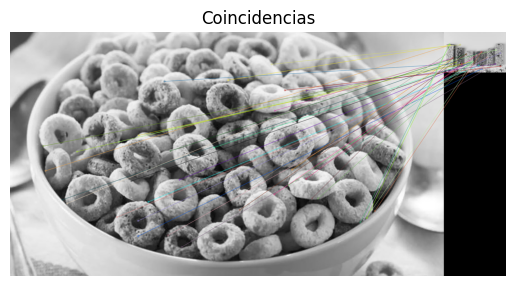

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen (asegúrate de tener la imagen en la misma carpeta o proporcionar la ruta completa)
image = cv2.imread('barritas.png', cv2.IMREAD_GRAYSCALE)  # Lee la imagen en escala de grises

# Definir los valores de sigma
sigma_values = [0.5, 2, 5.5, 8, 11, 15.5, 20, 24.5]

# Crear una figura para mostrar las imágenes filtradas
plt.figure(figsize=(12, 4))

# Aplicar el filtro gaussiano con los diferentes valores de sigma
for i, sigma in enumerate(sigma_values):
    # Calcular el tamaño del kernel en función de la desviación estándar
    ksize = int(2 * (sigma * 3) + 1)  # Se suele usar un tamaño de kernel de 6 veces sigma más 1
    # Asegurar que ksize es impar
    ksize = ksize + 1 if ksize % 2 == 0 else ksize # If ksize is even, add 1 to make it odd
    # Aplicar el filtro gaussiano
    filtered_image = cv2.GaussianBlur(image, (ksize, ksize), sigma)

    # Guardar la imagen filtrada con un nombre específico
    output_filename = f'filtered_image_sigma_{sigma}.jpg'
    cv2.imwrite(output_filename, filtered_image)

    # Mostrar la imagen filtrada
    plt.subplot(1, len(sigma_values), i + 1)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(f'FG (σ={sigma})')
    plt.axis('off')

# Mostrar la gráfica
plt.show()

print("Las imágenes filtradas se han guardado correctamente.")


import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen (asegúrate de tener la imagen en la misma carpeta o proporcionar la ruta completa)


# Definir los valores de sigma
sigma_values = [0.5, 2, 5.5, 8, 11, 15.5, 20, 24.5]

# Crear un diccionario para almacenar las imágenes filtradas
filtered_images = {}

# Crear una figura para mostrar las imágenes filtradas
plt.figure(figsize=(12, 4))

# Aplicar el filtro gaussiano con los diferentes valores de sigma
for i, sigma in enumerate(sigma_values):
    # Calcular el tamaño del kernel en función de la desviación estándar
    ksize = int(2 * (sigma * 3) + 1)  # Se suele usar un tamaño de kernel de 6 veces sigma más 1
    # Asegurar que ksize es impar
    ksize = ksize + 1 if ksize % 2 == 0 else ksize # If ksize is even, add 1 to make it odd
    # Aplicar el filtro gaussiano
    filtered_image = cv2.GaussianBlur(image, (ksize, ksize), sigma)

    # Guardar la imagen filtrada
    filtered_images[sigma] = filtered_image

    # Mostrar la imagen filtrada
    plt.subplot(1, len(sigma_values), i + 1)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(f'Filtro Gaussiano (σ={sigma})')
    plt.axis('off')

# Mostrar la gráfica
plt.show()

# Calcular y mostrar las diferencias entre las imágenes
for i, sigma1 in enumerate(sigma_values):
    for j, sigma2 in enumerate(sigma_values):
        if sigma1 < sigma2:  # Evitar comparar una imagen consigo misma
            diff = cv2.absdiff(filtered_images[sigma1], filtered_images[sigma2])  # Diferencia absoluta entre imágenes
            diff_filename = f'difference_sigma_{sigma1}_vs_{sigma2}.jpg'
            cv2.imwrite(diff_filename, diff)  # Guardar la imagen de la diferencia

            # Mostrar la diferencia
            plt.figure(figsize=(6, 6))
            plt.imshow(diff, cmap='gray')
            plt.title(f'Diferencia entre σ={sigma1} y σ={sigma2}')
            plt.axis('off')
            plt.show()

print("Las diferencias entre las imágenes han sido calculadas y guardadas correctamente.")

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar la imagen en escala de grises

# Crear el detector de características SIFT
sift = cv2.SIFT_create()

# Detectar los puntos clave (keypoints) y calcular descriptores
keypoints, descriptors = sift.detectAndCompute(image, None)

# Dibujar los puntos clave en la imagen original
image_with_keypoints = cv2.drawKeypoints(image, keypoints, None)

# Mostrar la imagen con los puntos clave detectados
plt.imshow(image_with_keypoints)
plt.title("Puntos clave detectados con SIFT")
plt.axis('off')  # Ocultar los ejes
plt.show()
import cv2
import numpy as np

# Cargar las dos imágenes
img1 = cv2.imread('cereal.png', cv2.IMREAD_GRAYSCALE)  # Imagen de consulta
img2 = cv2.imread('barritas.png', cv2.IMREAD_GRAYSCALE)  # Imagen de referencia

# Crear el detector SIFT
sift = cv2.SIFT_create()

# Detectar puntos clave y descriptores
keypoints1, descriptors1 = sift.detectAndCompute(img1, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# Crear el objeto de coincidencias con KNN
bf = cv2.BFMatcher()

# Coincidencias más cercanas con KNN
matches = bf.knnMatch(descriptors1, descriptors2, k=2)

# Aplicar la prueba de ratio de Lowe para filtrar coincidencias
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Dibujar las coincidencias
img_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Mostrar las coincidencias
# cv2.imshow("Coincidencias", img_matches)
# cv2.waitKey(0)
# cv2.destroyAllWindows()

plt.imshow(img_matches)
plt.title("Coincidencias")
plt.axis('off')  # Ocultar los ejes
plt.show()


sift = cv2.SIFT_create(nfeatures=500)  # Limitar a 500 características

